# Lennard-Jones, Symbolically — Force, Integral, and the Equation of Motion

The numeric MD notebook simulated the LJ potential; here SymPy does the *exact* calculus on it. From
$V(r)=4\epsilon[(\sigma/r)^{12}-(\sigma/r)^6]$ we derive — symbolically and verified —

- the **force** $F=-dV/dr$;
- the **equilibrium** $dV/dr=0\Rightarrow r_{\min}=2^{1/6}\sigma$, with $V_{\min}=-\epsilon$;
- the **integral** $\int V\,dr\ (+C)$;
- the **harmonic approximation**: Taylor-expand around $r_{\min}$, read off the spring constant
  $k=V''(r_{\min})$ and the bond vibration frequency $\omega=\sqrt{k/m}$;
- the **equation of motion** ODE $m\ddot r=-dV/dr$, which near the minimum is a simple harmonic
  oscillator.

Engine: `lennard_jones.symbolic_lj` + `sympy.init_printing`.

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))

import sympy as sp
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, Math
from dgs import lennard_jones as lj

sp.init_printing(use_latex="mathjax")
S = lj.symbolic_lj()                     # fully symbolic eps, sigma, r
r, eps, sigma = S["r"], S["eps"], S["sigma"]
print("symbolic LJ loaded")

symbolic LJ loaded


## §1 Potential, force, and the equilibrium

The force is minus the gradient; setting it to zero gives the bottom of the well at exactly
$2^{1/6}\sigma$ with depth $-\epsilon$ — both fall straight out of `sympy.solve`.

In [2]:
display(Math(r"V(r) = " + sp.latex(S["V"])))
display(Math(r"F(r) = -\frac{dV}{dr} = " + sp.latex(S["force"])))
display(Math(r"\frac{dV}{dr}=0\ \Rightarrow\ r_{\min} = " + sp.latex(S["r_min"])
             + r",\qquad V_{\min} = " + sp.latex(S["V_min"])))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

## §2 The indefinite integral (+C)

$\int V\,dr$ in closed form — verified by differentiating it back to $V$.

In [3]:
I = S["integral"]
display(Math(r"\int V(r)\,dr = " + sp.latex(sp.simplify(I)) + r" + C"))
print("d/dr of the integral == V ?", sp.simplify(sp.diff(I, r) - S["V"]) == 0)

<IPython.core.display.Math object>

d/dr of the integral == V ? True


## §3 Harmonic approximation — Taylor-expand around the minimum

Near $r_{\min}$ the well is a parabola: $V\approx V_{\min}+\tfrac12 k\,(r-r_{\min})^2$ with spring
constant $k=V''(r_{\min})$. Loop over expansion orders to watch the anharmonic corrections appear,
and read off the vibration frequency $\omega=\sqrt{k/m}$.

In [4]:
k = S["curvature"]
display(Math(r"k = V''(r_{\min}) = " + sp.latex(k)
             + r",\qquad \omega = \sqrt{k/m} = " + sp.latex(lj.harmonic_frequency())))

# loop over Taylor orders around r_min (the sympy loop)
for order in (2, 3, 4):
    taylor = sp.series(S["V"], r, S["r_min"], order).removeO()
    display(Math(rf"\text{{order {order}:}}\quad V \approx " + sp.latex(sp.simplify(taylor))))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

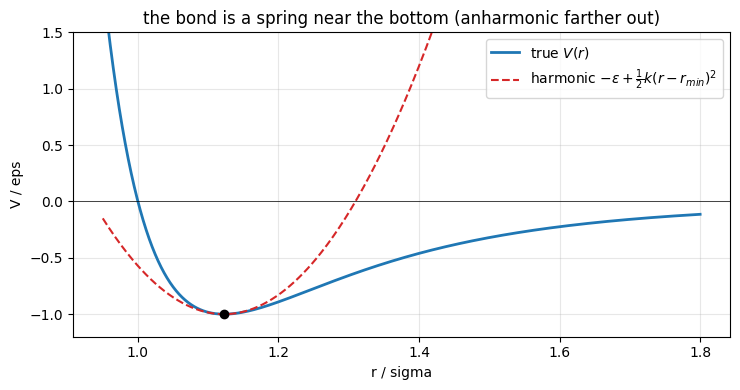

In [5]:
# plot: true LJ vs the harmonic (order-2) approximation near the minimum
Vn = sp.lambdify(r, S["V"].subs({eps: 1, sigma: 1}), "numpy")
rmin = float(S["r_min"].subs(sigma, 1))
knum = float(k.subs({eps: 1, sigma: 1}))
rr = np.linspace(0.95, 1.8, 400)
harm = -1 + 0.5*knum*(rr - rmin)**2
plt.figure(figsize=(7.5, 4))
plt.plot(rr, Vn(rr), "C0", lw=2, label="true $V(r)$")
plt.plot(rr, harm, "C3--", lw=1.5, label="harmonic $-\\epsilon+\\frac{1}{2} k(r-r_{min})^2$")
plt.plot(rmin, -1, "ko"); plt.ylim(-1.2, 1.5); plt.axhline(0, color="k", lw=0.5)
plt.xlabel("r / sigma"); plt.ylabel("V / eps"); plt.legend()
plt.title("the bond is a spring near the bottom (anharmonic farther out)")
plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

## §4 The equation of motion — an ODE that becomes a SHO

Newton on the bond: $m\ddot r=-dV/dr=F(r)$. Substituting $r=r_{\min}+x$ and keeping the linear term
gives $m\ddot x=-k\,x$ — the simple harmonic oscillator, which `dsolve` integrates to a cosine at the
frequency from §3.

In [6]:
t = sp.Symbol("t", positive=True)
x = sp.Function("x")
m, ksym = sp.symbols("m k", positive=True)
ode = sp.Eq(m * x(t).diff(t, 2), -ksym * x(t))      # linearised about r_min
sol = sp.dsolve(ode, x(t))
display(Math(r"m\,\ddot x = -k\,x \quad\Rightarrow\quad " + sp.latex(sol)))
display(Math(r"\text{oscillation frequency } \omega = \sqrt{k/m} = " + sp.latex(lj.harmonic_frequency())))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

## §5 Connections

- **The vibration frequency is a spectral line.** $\omega=\sqrt{V''(r_{\min})/m}$ is what an infrared
  or Raman spectrometer reads when it measures a bond — the symbolic curvature here is a measurable
  number. The anharmonic terms from §3 are why real spectra have overtones that aren't exact multiples.
- **Same SHO, three notebooks.** The harmonic well here, the quantum oscillator in
  `applied_qm_engineering.ipynb` (energies $\hbar\omega(n+\tfrac12)$), and the RLC / pendulum
  second-order systems are the *same* $\ddot x=-\omega^2 x$ — the universal small-oscillation law.
- **Symbolic + numeric, together.** This notebook (exact calculus) and `lennard_jones_md.ipynb`
  (velocity-Verlet simulation) are the two halves: SymPy gives the equilibrium, spring constant, and
  frequency in closed form; MD shows the many-body dynamics those local properties build up to.

Engine: `lennard_jones.symbolic_lj` / `harmonic_frequency` (verified: $r_{\min}=2^{1/6}\sigma$,
$V_{\min}=-\epsilon$, $k=36\cdot2^{2/3}\epsilon/\sigma^2$), driven with `init_printing`.